# Unit 3, Day 6: Multi-Class, Multi-Label & Imbalanced Data Walkthrough

**Date:** Thursday, January 15, 2026  
**Instructor:** Abishek Ganesh

---

## What We'll Cover Today

1. **Multi-Class Classification** - Predicting one class from 3+ options (using Iris dataset)
2. **Multi-Label Classification** - Predicting multiple labels at once (using movie genres)
3. **Handling Imbalanced Data** - SMOTE and undersampling techniques

Let's dive in!

---

# Part 1: Multi-Class Classification

## The Iris Dataset

The Iris dataset is one of the most famous datasets in machine learning. It contains measurements of 150 iris flowers from 3 different species:
- **Setosa**
- **Versicolor**
- **Virginica**

Each flower has 4 features:
- Sepal length
- Sepal width
- Petal length
- Petal width

Our goal: **Given the 4 measurements, predict which species the flower belongs to.**

In [3]:
# First, let's import all the libraries we'll need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Our classifiers
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1: Load and Explore the Data

In [8]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame for easier viewing
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head(5)

Dataset shape: (150, 6)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [9]:
# Check the distribution of classes
print("Class distribution:")
print(df['species_name'].value_counts())
print("\nNotice: The dataset is perfectly balanced - 50 samples of each species!")

Class distribution:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Notice: The dataset is perfectly balanced - 50 samples of each species!


## Visualizing the Iris Data

Let's see how the different species compare visually. This helps us understand why classification works!

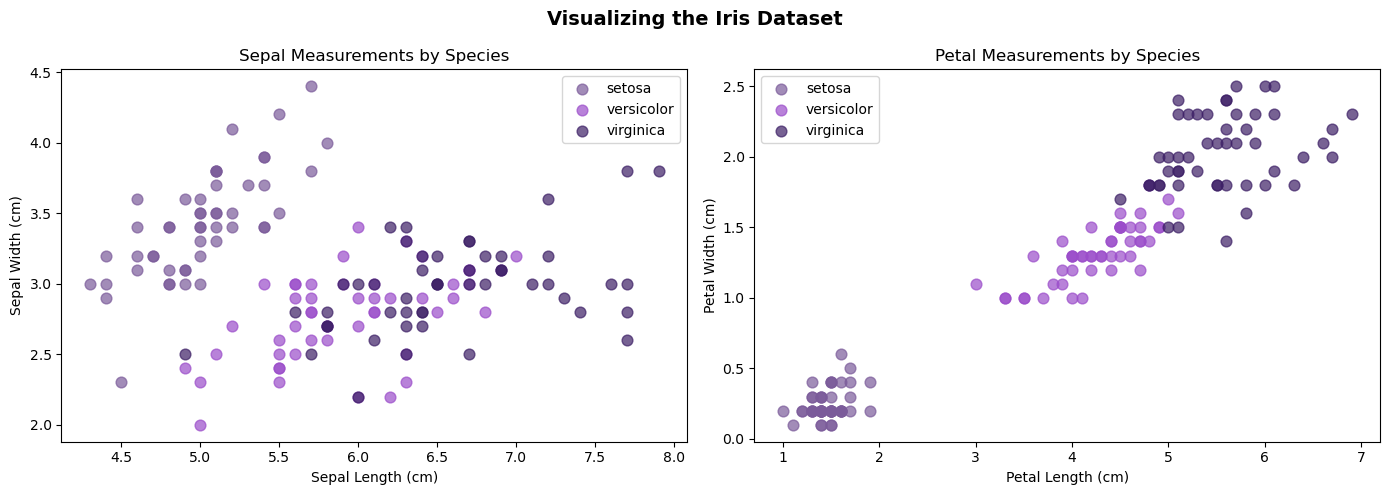


Notice how the species form clusters! This is why classification algorithms work well on this data.


In [10]:
# Visualize the Iris data - Scatter plot of 2 key features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define colors for each species
colors = {'setosa': '#7B5B9A', 'versicolor': '#9B4DCA', 'virginica': '#3D2066'}

# Plot 1: Sepal Length vs Sepal Width
for species in df['species_name'].unique():
    subset = df[df['species_name'] == species]
    axes[0].scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], 
                   label=species, c=colors[species], alpha=0.7, s=60)
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].set_title('Sepal Measurements by Species')
axes[0].legend()

# Plot 2: Petal Length vs Petal Width
for species in df['species_name'].unique():
    subset = df[df['species_name'] == species]
    axes[1].scatter(subset['petal length (cm)'], subset['petal width (cm)'], 
                   label=species, c=colors[species], alpha=0.7, s=60)
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].set_title('Petal Measurements by Species')
axes[1].legend()

plt.suptitle('Visualizing the Iris Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNotice how the species form clusters! This is why classification algorithms work well on this data.")

## Step 2: Prepare the Data for Training

In [11]:
# Separate features (X) and target (y)
X = iris.data
y = iris.target

print("Features shape:", X.shape)  # 150 samples, 4 features
print("Target shape:", y.shape)    # 150 labels

Features shape: (150, 4)
Target shape: (150,)


In [12]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Keep class balance in both sets
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 120 samples
Testing set: 30 samples


In [13]:
# Scale the features (important for KNN and SVM!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully!")
print("\nWhy scale? Some algorithms (like KNN and SVM) are sensitive to feature scales.")
print("Scaling ensures all features contribute equally.")

Data scaled successfully!

Why scale? Some algorithms (like KNN and SVM) are sensitive to feature scales.
Scaling ensures all features contribute equally.


---

## Algorithm 1: Naive Bayes

**How it works:** Uses probability theory (Bayes' theorem) to predict the most likely class. It's called "naive" because it assumes all features are independent of each other.

**Best for:** Text classification, spam detection, when you have limited data

In [14]:
# Create and train the Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Make predictions
nb_predictions = nb_model.predict(X_test_scaled)

# Evaluate
nb_accuracy = accuracy_score(y_test, nb_predictions)
print(f"Naive Bayes Accuracy: {nb_accuracy:.2%}")

Naive Bayes Accuracy: 96.67%


In [15]:
# Detailed classification report
print("Naive Bayes - Classification Report:")
print(classification_report(y_test, nb_predictions, target_names=iris.target_names))

Naive Bayes - Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



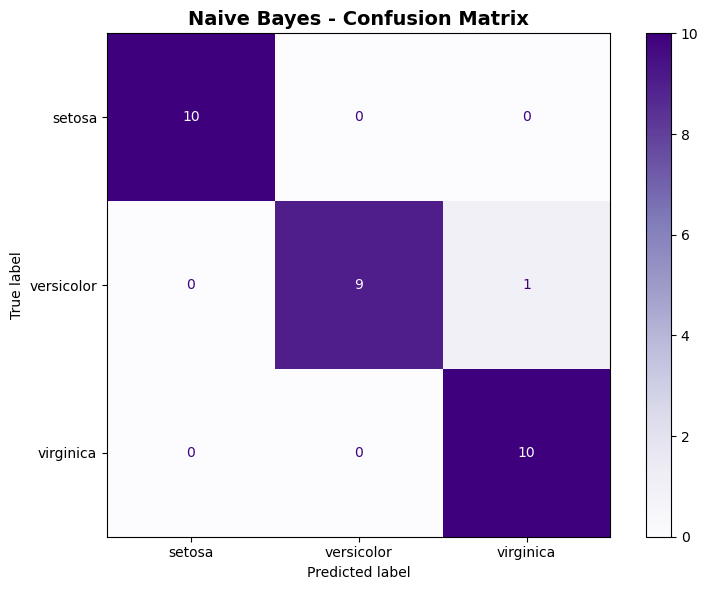


Reading the Confusion Matrix:
- Rows = Actual class
- Columns = Predicted class
- Diagonal = Correct predictions!


In [16]:
# Confusion Matrix for Naive Bayes
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
cm_nb = confusion_matrix(y_test, nb_predictions)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=iris.target_names)
disp_nb.plot(cmap='Purples', ax=plt.gca())
plt.title('Naive Bayes - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nReading the Confusion Matrix:")
print("- Rows = Actual class")
print("- Columns = Predicted class")
print("- Diagonal = Correct predictions!")

---

## Algorithm 2: K-Nearest Neighbors (KNN)

**How it works:** "You are who your neighbors are." To classify a new point, KNN finds the K closest training examples and takes a majority vote.

**Best for:** Pattern recognition, recommendation systems, when data has clear clusters

In [17]:
# Create and train the KNN model (using 5 neighbors)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Make predictions
knn_predictions = knn_model.predict(X_test_scaled)

# Evaluate
knn_accuracy = accuracy_score(y_test, knn_predictions)
print(f"KNN Accuracy: {knn_accuracy:.2%}")

KNN Accuracy: 93.33%


In [18]:
# Detailed classification report
print("KNN - Classification Report:")
print(classification_report(y_test, knn_predictions, target_names=iris.target_names))

KNN - Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



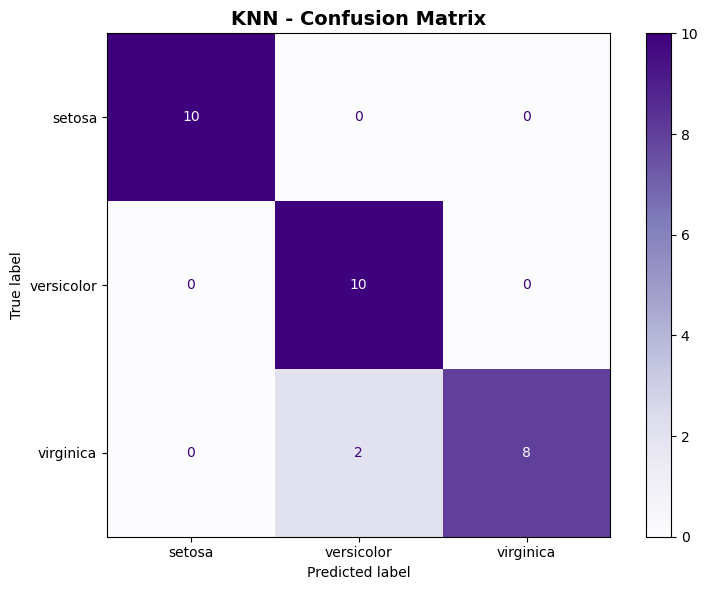

In [19]:
# Confusion Matrix for KNN
plt.figure(figsize=(8, 6))
cm_knn = confusion_matrix(y_test, knn_predictions)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=iris.target_names)
disp_knn.plot(cmap='Purples', ax=plt.gca())
plt.title('KNN - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Algorithm 3: Support Vector Machine (SVM)

**How it works:** Finds the best boundary (hyperplane) that separates different classes with maximum margin.

**Best for:** High-dimensional data, text classification, image recognition

In [20]:
# Create and train the SVM model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Make predictions
svm_predictions = svm_model.predict(X_test_scaled)

# Evaluate
svm_accuracy = accuracy_score(y_test, svm_predictions)
print(f"SVM Accuracy: {svm_accuracy:.2%}")

SVM Accuracy: 96.67%


In [21]:
# Detailed classification report
print("SVM - Classification Report:")
print(classification_report(y_test, svm_predictions, target_names=iris.target_names))

SVM - Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



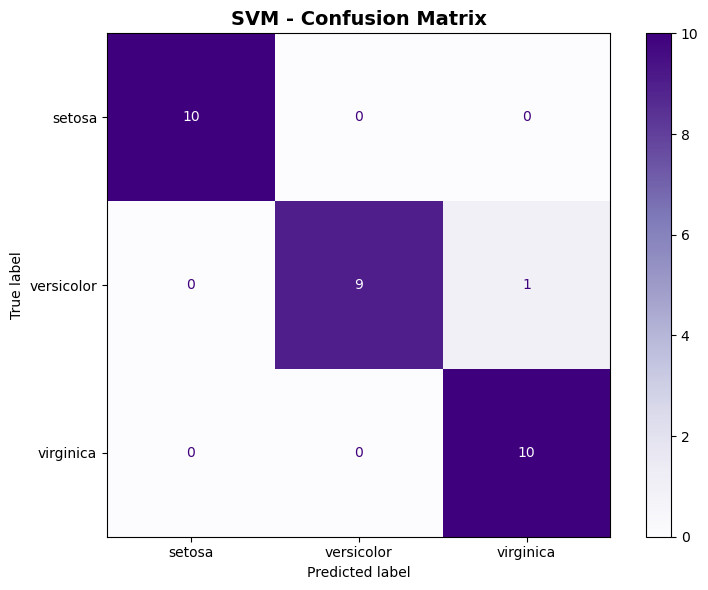

In [22]:
# Confusion Matrix for SVM
plt.figure(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, svm_predictions)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=iris.target_names)
disp_svm.plot(cmap='Purples', ax=plt.gca())
plt.title('SVM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Algorithm 4: Decision Tree

**How it works:** Creates a tree of if-then rules based on feature values. Easy to understand and visualize!

**Best for:** When you need explainability, feature importance analysis

In [23]:
# Create and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_scaled, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test_scaled)

# Evaluate
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy:.2%}")

Decision Tree Accuracy: 93.33%


In [24]:
# Detailed classification report
print("Decision Tree - Classification Report:")
print(classification_report(y_test, dt_predictions, target_names=iris.target_names))

Decision Tree - Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



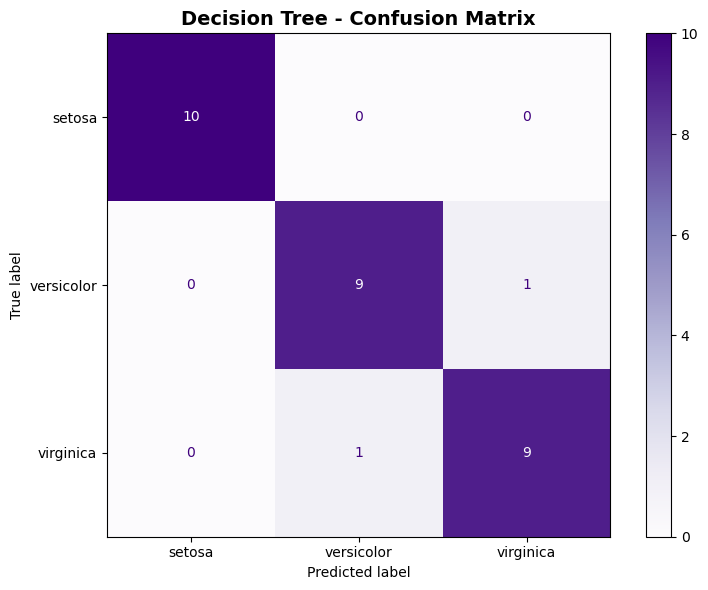

In [25]:
# Confusion Matrix for Decision Tree
plt.figure(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, dt_predictions)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=iris.target_names)
disp_dt.plot(cmap='Purples', ax=plt.gca())
plt.title('Decision Tree - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Algorithm 5: Random Forest

**How it works:** Builds multiple decision trees and combines their predictions through voting. More robust than a single tree!

**Best for:** General-purpose classification, when you need high accuracy and can sacrifice some interpretability

In [26]:
# Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test_scaled)

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 90.00%


In [27]:
# Detailed classification report
print("Random Forest - Classification Report:")
print(classification_report(y_test, rf_predictions, target_names=iris.target_names))

Random Forest - Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



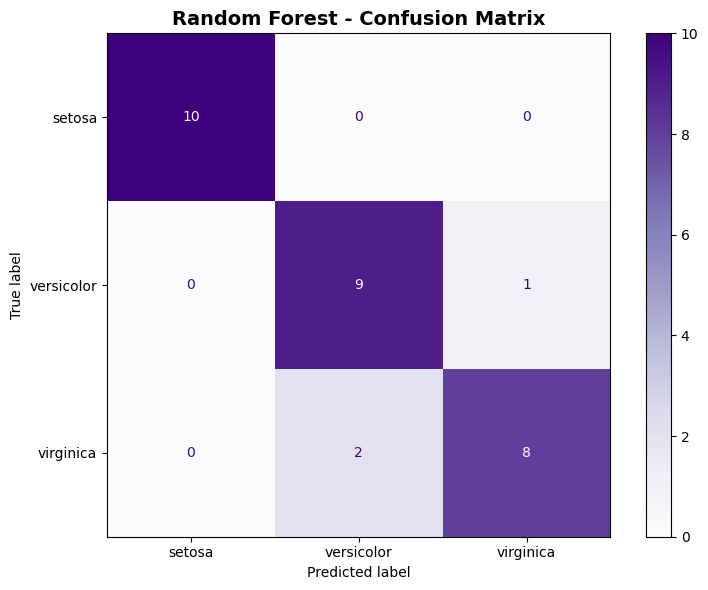

In [28]:
# Confusion Matrix for Random Forest
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, rf_predictions)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=iris.target_names)
disp_rf.plot(cmap='Purples', ax=plt.gca())
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Comparing All Multi-Class Models

In [29]:
# Create a summary comparison
results = {
    'Algorithm': ['Naive Bayes', 'KNN', 'SVM', 'Decision Tree', 'Random Forest'],
    'Accuracy': [nb_accuracy, knn_accuracy, svm_accuracy, dt_accuracy, rf_accuracy]
}

results_df = pd.DataFrame(results)
results_df['Accuracy'] = results_df['Accuracy'].apply(lambda x: f"{x:.2%}")
results_df = results_df.sort_values('Accuracy', ascending=False)

print("=" * 40)
print("Multi-Class Classification Results")
print("=" * 40)
print(results_df.to_string(index=False))

Multi-Class Classification Results
    Algorithm Accuracy
  Naive Bayes   96.67%
          SVM   96.67%
          KNN   93.33%
Decision Tree   93.33%
Random Forest   90.00%


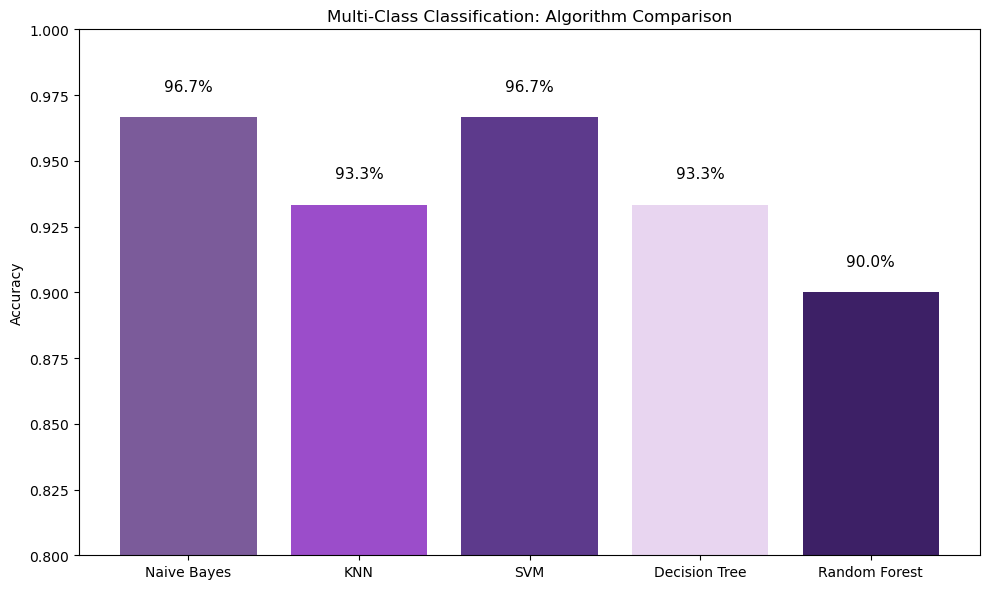

In [30]:
# Visualize the comparison
accuracies = [nb_accuracy, knn_accuracy, svm_accuracy, dt_accuracy, rf_accuracy]
algorithms = ['Naive Bayes', 'KNN', 'SVM', 'Decision Tree', 'Random Forest']

plt.figure(figsize=(10, 6))
bars = plt.bar(algorithms, accuracies, color=['#7B5B9A', '#9B4DCA', '#5D3A8C', '#E8D5F0', '#3D2066'])
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Multi-Class Classification: Algorithm Comparison')

# Add accuracy labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### Key Takeaway

All algorithms perform well on Iris because it's a clean, well-separated dataset. In the real world, results will vary more - that's why we try multiple algorithms!

---

# Part 2: Multi-Label Classification

## What's Different?

- **Multi-Class:** One item belongs to exactly ONE class (cat OR dog OR bird)
- **Multi-Label:** One item can belong to MULTIPLE classes (Action AND Comedy AND Sci-Fi)

## Example: Movie Genre Classification

A movie can be tagged with multiple genres simultaneously:
- "The Matrix" -> Action, Sci-Fi
- "Toy Story" -> Animation, Comedy, Family

In [31]:
# Let's create a simple synthetic movie dataset
from sklearn.multiclass import OneVsRestClassifier

# Synthetic movie features: [budget, runtime, year, rating]
# Labels: [Action, Comedy, Drama]
np.random.seed(42)

n_samples = 200

# Create features
X_movies = np.random.rand(n_samples, 4) * 100  # Random features

# Create multi-label targets (a movie can have multiple genres)
# Each row: [is_action, is_comedy, is_drama]
y_movies = np.zeros((n_samples, 3))

for i in range(n_samples):
    # Randomly assign 1-3 genres to each movie
    n_genres = np.random.randint(1, 4)
    genres = np.random.choice([0, 1, 2], size=n_genres, replace=False)
    y_movies[i, genres] = 1

print("Movie features shape:", X_movies.shape)
print("Movie labels shape:", y_movies.shape)
print("\nSample labels (first 5 movies):")
print("[Action, Comedy, Drama]")
print(y_movies[:5])

Movie features shape: (200, 4)
Movie labels shape: (200, 3)

Sample labels (first 5 movies):
[Action, Comedy, Drama]
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 0.]
 [0. 1. 1.]
 [1. 1. 1.]]


In [32]:
# Show what these labels mean
genres = ['Action', 'Comedy', 'Drama']
print("Interpreting the labels:\n")
for i in range(5):
    movie_genres = [genres[j] for j in range(3) if y_movies[i, j] == 1]
    print(f"Movie {i+1}: {', '.join(movie_genres)}")

Interpreting the labels:

Movie 1: Action, Comedy, Drama
Movie 2: Action, Comedy, Drama
Movie 3: Action, Comedy
Movie 4: Comedy, Drama
Movie 5: Action, Comedy, Drama


## Binary Relevance Approach

The simplest multi-label strategy: treat each label as a separate binary classification problem.

- Train one classifier for "Is it Action?" (yes/no)
- Train one classifier for "Is it Comedy?" (yes/no)
- Train one classifier for "Is it Drama?" (yes/no)

In [33]:
# Split the data
X_train_movies, X_test_movies, y_train_movies, y_test_movies = train_test_split(
    X_movies, y_movies, test_size=0.2, random_state=42
)

# Use OneVsRestClassifier for Binary Relevance approach
# This wraps any classifier to handle multi-label problems
multilabel_model = OneVsRestClassifier(RandomForestClassifier(n_estimators=50, random_state=42))
multilabel_model.fit(X_train_movies, y_train_movies)

# Make predictions
multilabel_predictions = multilabel_model.predict(X_test_movies)

print("Multi-label model trained!")
print("\nSample predictions (first 5 test movies):")
print("[Action, Comedy, Drama]")
print(multilabel_predictions[:5])

Multi-label model trained!

Sample predictions (first 5 test movies):
[Action, Comedy, Drama]
[[0 1 1]
 [0 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]]


In [34]:
# Evaluate multi-label performance
from sklearn.metrics import hamming_loss, accuracy_score

# Hamming Loss: fraction of labels that are incorrectly predicted
h_loss = hamming_loss(y_test_movies, multilabel_predictions)

# Subset Accuracy: percentage of samples where ALL labels match exactly
subset_acc = accuracy_score(y_test_movies, multilabel_predictions)

print("Multi-Label Evaluation Metrics:")
print(f"  Hamming Loss: {h_loss:.3f} (lower is better)")
print(f"  Subset Accuracy: {subset_acc:.2%} (exact match of all labels)")
print("\nNote: Subset accuracy is strict - ALL labels must match perfectly!")

Multi-Label Evaluation Metrics:
  Hamming Loss: 0.383 (lower is better)
  Subset Accuracy: 22.50% (exact match of all labels)

Note: Subset accuracy is strict - ALL labels must match perfectly!


### Multi-Label Key Takeaway

Multi-label is trickier than multi-class because:
1. Each sample can have multiple correct answers
2. We need different evaluation metrics (Hamming Loss, Subset Accuracy)
3. Binary Relevance is a simple but effective starting approach

---

# Part 3: Handling Imbalanced Data

## The Problem

What happens when one class dominates your dataset?

Example: Fraud detection where 99% of transactions are legitimate.

A model that ALWAYS predicts "not fraud" would be 99% accurate but completely useless!

In [35]:
# Create a synthetic imbalanced dataset
# 95% class 0 (majority), 5% class 1 (minority)

X_imbalanced, y_imbalanced = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_clusters_per_class=1,
    weights=[0.95, 0.05],  # 95% class 0, 5% class 1
    flip_y=0,
    random_state=42
)

print("Imbalanced Dataset Created!")
print(f"\nClass distribution:")
print(f"  Class 0 (Majority): {sum(y_imbalanced == 0)} samples ({sum(y_imbalanced == 0)/len(y_imbalanced):.1%})")
print(f"  Class 1 (Minority): {sum(y_imbalanced == 1)} samples ({sum(y_imbalanced == 1)/len(y_imbalanced):.1%})")

Imbalanced Dataset Created!

Class distribution:
  Class 0 (Majority): 950 samples (95.0%)
  Class 1 (Minority): 50 samples (5.0%)


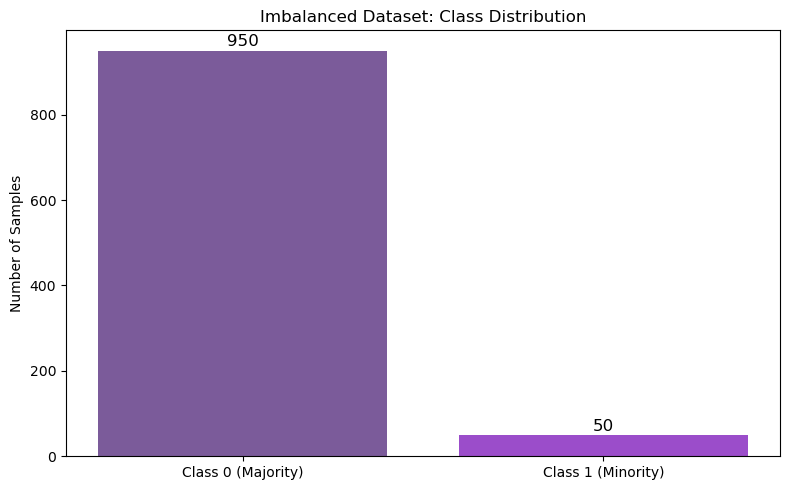

In [36]:
# Visualize the imbalance
plt.figure(figsize=(8, 5))
counts = [sum(y_imbalanced == 0), sum(y_imbalanced == 1)]
plt.bar(['Class 0 (Majority)', 'Class 1 (Minority)'], counts, color=['#7B5B9A', '#9B4DCA'])
plt.ylabel('Number of Samples')
plt.title('Imbalanced Dataset: Class Distribution')

for i, count in enumerate(counts):
    plt.text(i, count + 10, str(count), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## First: Let's See the Problem

What happens if we just train a model without handling the imbalance?

In [37]:
# Split the imbalanced data
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imbalanced, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced
)

# Train a model WITHOUT handling imbalance
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_model.fit(X_train_imb, y_train_imb)
baseline_predictions = baseline_model.predict(X_test_imb)

print("Baseline Model (No imbalance handling):")
print(f"Accuracy: {accuracy_score(y_test_imb, baseline_predictions):.2%}")
print("\nClassification Report:")
print(classification_report(y_test_imb, baseline_predictions, target_names=['Majority', 'Minority']))

Baseline Model (No imbalance handling):
Accuracy: 99.00%

Classification Report:
              precision    recall  f1-score   support

    Majority       0.99      1.00      0.99       190
    Minority       1.00      0.80      0.89        10

    accuracy                           0.99       200
   macro avg       0.99      0.90      0.94       200
weighted avg       0.99      0.99      0.99       200



### Notice the Problem!

The accuracy looks great, but look at the **recall for the minority class** - it's often very low! The model struggles to identify the rare class because it's learned to favor the majority.

---

## Technique 1: SMOTE (Synthetic Minority Over-sampling Technique)

**How it works:** Creates synthetic (fake but realistic) examples of the minority class by interpolating between existing minority samples.

**Result:** More balanced training data without losing any original samples.

In [39]:
# Install imbalanced-learn if needed (run this once)
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imb, y_train_imb)

print("Before SMOTE:")
print(f"  Class 0: {sum(y_train_imb == 0)} samples")
print(f"  Class 1: {sum(y_train_imb == 1)} samples")

print("\nAfter SMOTE:")
print(f"  Class 0: {sum(y_train_smote == 0)} samples")
print(f"  Class 1: {sum(y_train_smote == 1)} samples")
print("\nNow balanced!")

Before SMOTE:
  Class 0: 760 samples
  Class 1: 40 samples

After SMOTE:
  Class 0: 760 samples
  Class 1: 760 samples

Now balanced!


In [40]:
# Train a model on SMOTE-balanced data
smote_model = RandomForestClassifier(n_estimators=100, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)
smote_predictions = smote_model.predict(X_test_imb)

print("SMOTE Model Results:")
print(f"Accuracy: {accuracy_score(y_test_imb, smote_predictions):.2%}")
print("\nClassification Report:")
print(classification_report(y_test_imb, smote_predictions, target_names=['Majority', 'Minority']))

SMOTE Model Results:
Accuracy: 98.50%

Classification Report:
              precision    recall  f1-score   support

    Majority       0.99      0.99      0.99       190
    Minority       0.82      0.90      0.86        10

    accuracy                           0.98       200
   macro avg       0.91      0.94      0.92       200
weighted avg       0.99      0.98      0.99       200



### Compare the Minority Class Recall!

SMOTE typically improves the recall for the minority class - we're now catching more of those rare but important cases!

---

## Technique 2: Random Undersampling

**How it works:** Randomly removes samples from the majority class until the classes are balanced.

**Trade-off:** Faster training, but we lose potentially useful data.

In [41]:
from imblearn.under_sampling import RandomUnderSampler

# Apply undersampling to the training data
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_imb, y_train_imb)

print("Before Undersampling:")
print(f"  Class 0: {sum(y_train_imb == 0)} samples")
print(f"  Class 1: {sum(y_train_imb == 1)} samples")

print("\nAfter Undersampling:")
print(f"  Class 0: {sum(y_train_under == 0)} samples")
print(f"  Class 1: {sum(y_train_under == 1)} samples")
print("\nBalanced, but with much less data!")

Before Undersampling:
  Class 0: 760 samples
  Class 1: 40 samples

After Undersampling:
  Class 0: 40 samples
  Class 1: 40 samples

Balanced, but with much less data!


In [42]:
# Train a model on undersampled data
under_model = RandomForestClassifier(n_estimators=100, random_state=42)
under_model.fit(X_train_under, y_train_under)
under_predictions = under_model.predict(X_test_imb)

print("Undersampling Model Results:")
print(f"Accuracy: {accuracy_score(y_test_imb, under_predictions):.2%}")
print("\nClassification Report:")
print(classification_report(y_test_imb, under_predictions, target_names=['Majority', 'Minority']))

Undersampling Model Results:
Accuracy: 95.00%

Classification Report:
              precision    recall  f1-score   support

    Majority       0.99      0.95      0.97       190
    Minority       0.50      0.90      0.64        10

    accuracy                           0.95       200
   macro avg       0.75      0.93      0.81       200
weighted avg       0.97      0.95      0.96       200



---

## Comparing All Approaches for Imbalanced Data

In [43]:
from sklearn.metrics import recall_score, f1_score

# Calculate metrics for minority class (class 1)
results_imb = {
    'Approach': ['Baseline (No handling)', 'SMOTE', 'Undersampling'],
    'Accuracy': [
        accuracy_score(y_test_imb, baseline_predictions),
        accuracy_score(y_test_imb, smote_predictions),
        accuracy_score(y_test_imb, under_predictions)
    ],
    'Minority Recall': [
        recall_score(y_test_imb, baseline_predictions, pos_label=1),
        recall_score(y_test_imb, smote_predictions, pos_label=1),
        recall_score(y_test_imb, under_predictions, pos_label=1)
    ],
    'F1 Score': [
        f1_score(y_test_imb, baseline_predictions, pos_label=1),
        f1_score(y_test_imb, smote_predictions, pos_label=1),
        f1_score(y_test_imb, under_predictions, pos_label=1)
    ]
}

results_imb_df = pd.DataFrame(results_imb)
print("=" * 60)
print("Imbalanced Data: Technique Comparison")
print("=" * 60)
print(results_imb_df.to_string(index=False))

Imbalanced Data: Technique Comparison
              Approach  Accuracy  Minority Recall  F1 Score
Baseline (No handling)     0.990              0.8  0.888889
                 SMOTE     0.985              0.9  0.857143
         Undersampling     0.950              0.9  0.642857


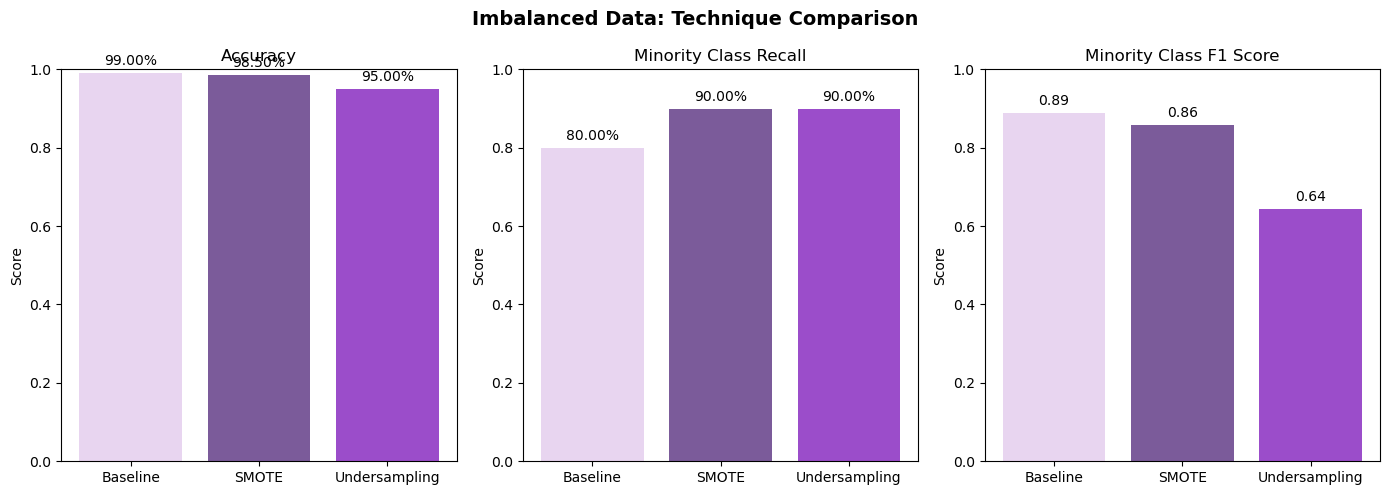

In [44]:
# Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

approaches = ['Baseline', 'SMOTE', 'Undersampling']
colors = ['#E8D5F0', '#7B5B9A', '#9B4DCA']

# Accuracy
axes[0].bar(approaches, results_imb['Accuracy'], color=colors)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Score')
axes[0].set_title('Accuracy')
for i, v in enumerate(results_imb['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.2%}', ha='center')

# Minority Recall
axes[1].bar(approaches, results_imb['Minority Recall'], color=colors)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Score')
axes[1].set_title('Minority Class Recall')
for i, v in enumerate(results_imb['Minority Recall']):
    axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center')

# F1 Score
axes[2].bar(approaches, results_imb['F1 Score'], color=colors)
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Score')
axes[2].set_title('Minority Class F1 Score')
for i, v in enumerate(results_imb['F1 Score']):
    axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center')

plt.suptitle('Imbalanced Data: Technique Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Takeaways for Imbalanced Data

1. **Don't trust accuracy alone!** A model can have high accuracy while being useless for the minority class.

2. **SMOTE** creates synthetic minority samples - good when you want to preserve all your original data.

3. **Undersampling** removes majority samples - faster but loses information.

4. **Always check recall and F1 for the minority class** - these tell you if you're actually catching the rare cases.

---

# Summary: What We Learned Today

## Multi-Class Classification
- One prediction from 3+ classes
- Algorithms: Naive Bayes, KNN, SVM, Decision Trees, Random Forest
- All work natively with multi-class problems in sklearn!

## Multi-Label Classification
- Multiple predictions per sample
- Binary Relevance: treat each label as a separate binary problem
- Different metrics: Hamming Loss, Subset Accuracy

## Imbalanced Data
- When classes aren't equal (e.g., 95% vs 5%)
- SMOTE: create synthetic minority samples
- Undersampling: reduce majority samples
- Always check precision, recall, F1 - not just accuracy!

---

## Next Class: Practice Week!

All of next week we'll be building models hands-on. Get ready to practice everything we've learned!